In [1]:
import os
os.chdir("..")
print(os.getcwd())

c:\Users\NASA2004\OneDrive\Documents\transformer-from-scratch


In [2]:
def warmup_lr_lambda(step_num, d_model, warmup_steps):
    step_num = max(step_num, 1)
    return (d_model ** -0.5) * min(step_num ** -0.5, step_num * warmup_steps ** -1.5)

In [7]:
import torch
import torch.optim as optim
from src.model import Transformer

vocab_size = 8000
model = Transformer(vocab_size, pad_id=0)

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda step: warmup_lr_lambda(step, d_model=512, warmup_steps=4000)
)

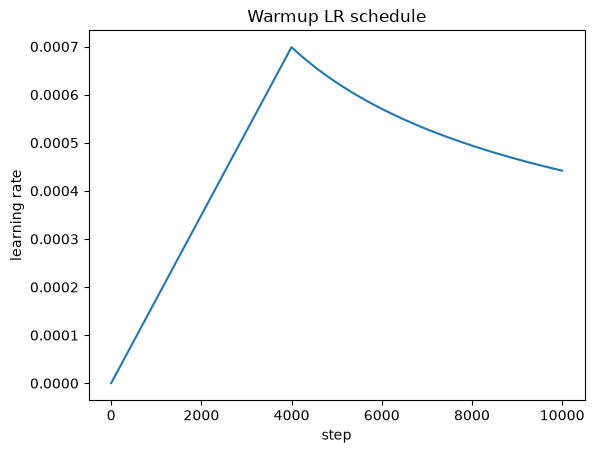

In [8]:
import matplotlib.pyplot as plt

lrs = [warmup_lr_lambda(step, d_model=512, warmup_steps=4000) for step in range(1, 10000)]
plt.plot(lrs)
plt.xlabel("step")
plt.ylabel("learning rate")
plt.title("Warmup LR schedule")
plt.savefig("figures/scheduler_lr_curve.png")
plt.show()